# The Jupyter Notebook that Analyses R  
**Damian**

---

This notebook is structured as follows:

In the first cell below, an overview is given of the research into the observational biases that affect luminosity ($L$) and effective temperature ($T_{\mathrm{eff}}$), and therefore also influence the derived stellar radius ($R$) and all associated ratios. In the same cell, following the explanation of these biases and their effects, methods for correcting these biases are discussed.

In the next cell (not yet created), all required imports will be included.

In the cell after that (also not yet created), the necessary data will be loaded.

Finally, in the following cell (also not yet created), the data analysis and bias correction will be performed.

# Information about the biases affecting R.

This section summarizes the main observational biases affecting binary star systems, and how these biases influence the measured luminosity ($L$), effective temperature ($T_{\mathrm{eff}}$), and derived stellar radius ($R$), as well as their ratios.

---

## 1. Luminosity (Brightness) Bias

**Explanation**  
Brighter systems are easier to detect than faint systems, especially at larger distances. As a result, intrinsically luminous stars and systems are overrepresented in the dataset, while faint systems fall below the detection threshold.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
This bias leads to an overestimation of the average luminosity $L$. Since hotter stars are generally more luminous, the average effective temperature $T_{\mathrm{eff}}$ is also biased toward higher values. Because the stellar radius depends on both parameters,
$$
R \propto \frac{\sqrt{L}}{T_{\mathrm{eff}}^2},
$$
an increase in $L$ leads to larger inferred radii, while an increase in $T_{\mathrm{eff}}$ partially counteracts this effect.

**Effect on Ratios**  
Systems with large luminosity differences are harder to detect, so luminosity ratios tend to be biased toward values closer to 1. Extreme ratios are underrepresented.

---

## 2. Temperature Bias

**Explanation**  
Hotter stars are brighter and have clearer spectral features, making them easier to detect and analyze. Cooler stars are fainter and can be more difficult to identify, especially in binary systems.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
This bias results in an overrepresentation of stars with high $T_{\mathrm{eff}}$. Since temperature and luminosity are correlated, $L$ is also biased toward higher values. Because $R \propto T^{-2}$, an overestimated temperature can lead to underestimated stellar radii.

**Effect on Ratios**  
Cooler secondary stars are more likely to be missed or poorly measured, causing temperature ratios to cluster closer to 1 and reducing the number of systems with large temperature contrasts.

---

## 3. Mass-Ratio Bias

**Explanation**  
Binary systems with similar components (mass ratio $q \approx 1$) are easier to detect than systems where one star is much fainter than the other. In high-contrast systems, the secondary component may be lost in the light of the primary.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
Because similar-component systems are overrepresented, the measured values of $L$ and $T_{\mathrm{eff}}$ for the two stars tend to be more alike. This also leads to less variation in the derived stellar radii.

**Effect on Ratios**  
Ratios such as $L_1/L_2$, $T_1/T_2$, and $R_1/R_2$ are biased toward unity, while extreme values are underrepresented.

---

## 4. Inclination Bias

**Explanation**  
The detection of certain binary systems depends on their orbital inclination. For example, eclipsing binaries are only observable when the system is viewed nearly edge-on.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
This bias selects systems that are easier to characterize, leading to more reliable measurements of $L$, $T_{\mathrm{eff}}$, and $R$. However, these systems are not necessarily representative of the full binary population.

**Effect on Ratios**  
Ratios in these systems are often more accurately determined, but the sample is biased toward systems that are favorable for observation, which may indirectly affect the observed distribution.

---

## 5. Period Bias

**Explanation**  
Short-period binaries are easier to detect because they show more frequent eclipses and larger radial velocity variations. Long-period systems are less likely to be identified as binaries.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
Short-period systems often experience interactions such as tidal locking or mass transfer, which can make the component stars more similar in temperature and luminosity. This can influence the measured distributions of $L$ and $T_{\mathrm{eff}}$.

**Effect on Ratios**  
Because the components tend to be more similar, the ratios $L_1/L_2$, $T_1/T_2$, and $R_1/R_2$ are more likely to be close to 1.

---

## 6. Blending / Unresolved Bias

**Explanation**  
In some cases, two stars cannot be resolved individually and appear as a single object. This is especially common when one component is much fainter than the other.

**Effect on $L$, $T_{\mathrm{eff}}$, and $R$**  
The measured flux is then a combination of both stars, leading to an overestimation of $L$ and a distorted estimate of $T_{\mathrm{eff}}$. This propagates into errors in the derived stellar radius $R$.

**Effect on Ratios**  
Systems with large differences between components may be misidentified as single stars and therefore excluded from the dataset. As a result, extreme ratios are underrepresented, and observed ratios are biased toward values near 1.

In [39]:
# Imports here:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Inlezen en eerste processing van data zodat analyse mogelijk is


# ============================================================
# 1. Data inlezen
# ============================================================

df = pd.read_csv(r'DATA/RAW/L_SP.csv')
df_L = None
df_sp = None

print("Totaal aantal rows:", len(df))

# ============================================================
# 2. Overzicht van databases/catalogi
# ============================================================

print("\n===== DATABASE OVERZICHT =====")

catalogue_counts = (
    df["catalogue"]
    .value_counts()
    .reset_index()
)

catalogue_counts.columns = ["catalogue", "n_rows"]

print(catalogue_counts)

# ============================================================
# 3. system_id en component uit bsdb halen
# ============================================================

# voorbeeld:
# J000026.44+242931.2:c1
#
# -> system_id = J000026.44+242931.2
# -> component = c1

df[["system_id", "component"]] = (
    df["bsdb"]
    .str.split(":", expand=True)
)


# ============================================================
# 4. Alleen rows behouden met bekende luminositeit (L)
# ============================================================

df_L = df.copy()

df_L["L"] = df_L["L"].replace("", pd.NA)
df_L = df_L.dropna(subset=["L"])

df_L["L"] = pd.to_numeric(df_L["L"], errors="coerce")
df_L = df_L.dropna(subset=["L"])

print("Rows met bekende L:", len(df_L))

# ============================================================
# 5. Controle van beschikbare luminosity catalogi
# ============================================================

print("\n===== LUMINOSITY CATALOGI =====")

luminosity_catalogues = (
    df_L["catalogue"]
    .value_counts()
)

print("df_L rows:", len(df_L))

print("\n===== LUMINOSITY CATALOGI =====")

luminosity_catalogues = (
    df_L["catalogue"]
    .value_counts()
    .rename_axis("catalogue")
    .reset_index(name="n_rows")
)

print(luminosity_catalogues.to_string(index=False))


# ============================================================
# 6. MNRAS luminosities omzetten
# ============================================================

# J/MNRAS/491/5489 gebruikt:
# log10(L/Lsun)
#
# omzetting:
# L/Lsun = 10^(logL)

mask_mnras = (
    df_L["catalogue"] == "J/MNRAS/491/5489"
)

df_L.loc[mask_mnras, "L"] = (
    10 ** df_L.loc[mask_mnras, "L"]
)

print(
    "\nMNRAS luminosities omgezet van "
    "log(L/Lsun) naar L/Lsun"
)



# ============================================================
# 7. Alleen rows behouden met bekende spectraalklasse
# ============================================================

df_sp = df.copy()

# lege strings / whitespace → NaN
df_sp["spType"] = df_sp["spType"].replace("", pd.NA)
df_sp["spType"] = df_sp["spType"].astype(str).str.strip()

# eventueel "nan" strings opruimen (komen vaak voor na copy/CSV load)
invalid_values = ["nan", "NaN", "null", "---", "..."]
df_sp.loc[df_sp["spType"].isin(invalid_values), "spType"] = pd.NA

# alleen rows met geldige spectraalklasse behouden
df_sp = df_sp.dropna(subset=["spType"])

print("Rows met bekende spectraalklasse:", len(df_sp))


# ============================================================
# 8: V/118 database uitbreiden naar de volledige dataframe (missende sterren toevoegen)
# ============================================================

df_v118 = df_L[df_L["catalogue"] == "V/118"].copy()
df_raw = df.copy()

print("V/118 rows:", len(df_v118))

new_rows = []

# ============================================================
# 8.1: loop over alle V/118 entries
# ============================================================

for _, row in df_v118.iterrows():

    system = row["system_id"]
    L_primary = row["L"]
    catalogue = row["catalogue"]

    # ========================================================
    # 8.2: check of companion AL IN df_L zit (alle catalogi)
    # ========================================================

    comps_in_L = set(
        df_L[df_L["system_id"] == system]["component"]
    )

    # als systeem al volledig (≥2 componenten in df_L), skip
    if len(comps_in_L) >= 2:
        continue

    # ========================================================
    # 8.3: haal echte system-structuur uit raw df
    # ========================================================

    comps_in_raw = set(
        df_raw[df_raw["system_id"] == system]["component"]
    )

    missing_comps = comps_in_raw - comps_in_L

    # ========================================================
    # 8.4: voeg missing component toe aan df_L
    # ========================================================

    for comp in missing_comps:

        new_rows.append({
            "system_id": system,
            "component": comp,
            "catalogue": catalogue,
            "L": 1 - L_primary
        })

# ============================================================
# 8.5: direct toevoegen aan df_L (geen extra dataframe)
# ============================================================

if len(new_rows) > 0:
    df_L = pd.concat([df_L, pd.DataFrame(new_rows)], ignore_index=True)

print("Nieuwe entries toegevoegd:", len(new_rows))
print("Nieuwe df_L size:", len(df_L))




Totaal aantal rows: 107881

===== DATABASE OVERZICHT =====
           catalogue  n_rows
0                WDS   60601
1               CCDM   34940
2             B/gcvs    3301
3            II/150A    2275
4                CEV    1949
5      J/A+A/417/263    1672
6      J/A+A/546/A69     740
7   J/MNRAS/491/5489     462
8       Svechnikov99     402
9       Svechnikov84     400
10             V/115     334
11             V/120     327
12            V/119      319
13            Perova     109
14             V/118      50
Rows met bekende L: 3368

===== LUMINOSITY CATALOGI =====
df_L rows: 3368

===== LUMINOSITY CATALOGI =====
       catalogue  n_rows
         II/150A    2275
J/MNRAS/491/5489     462
    Svechnikov84     400
    Svechnikov99     181
           V/118      50

MNRAS luminosities omgezet van log(L/Lsun) naar L/Lsun
Rows met bekende spectraalklasse: 106596



===== VOORBEELD =====
              system_id component      catalogue     L spType
0   J000001.10+385133.7        c1            WDS   NaN      B
1   J000001.10+385133.7        c1           CCDM   NaN      B
2   J000003.14+002133.3        c1            WDS   NaN      M
3   J000006.64+752859.7        c1            WDS   NaN      A
4   J000007.30+184417.0        c1        II/150A  6.58      A
5   J000007.30+184417.0        c1            CEV   NaN      A
6   J000007.30+184417.0        c1         B/gcvs   NaN      A
7   J000007.30+184417.0        c1  J/A+A/417/263   NaN      B
8   J000007.30+184417.0        c1  J/A+A/417/263   NaN      S
9   J000007.30+184417.0        c2        II/150A  7.36    NaN
10  J000009.76-251928.8        c1           CCDM   NaN      G
11  J000009.76-251928.8        c1            WDS   NaN      G
12  J000009.76-251928.8        c2           CCDM   NaN      G
13  J000010.39-002036.3        c1            WDS   NaN      G
14  J000010.39-002036.3        c2            WD

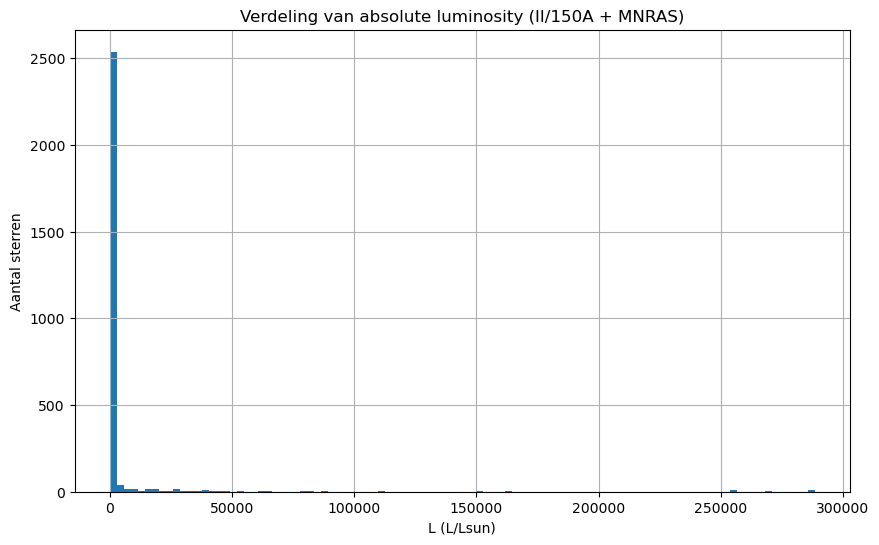


===== PER CATALOGUE STATISTIEK VAN L =====
                   count          mean           std       min       25%  \
catalogue                                                                  
II/150A           2275.0   2196.627029  17950.782399  0.010000  2.820000   
J/MNRAS/491/5489   462.0  10941.081077  42882.733327  0.389045  5.284833   
Svechnikov84       400.0      0.706829      0.205865  0.043000  0.570000   
Svechnikov99       181.0      0.672525      0.151934  0.488000  0.545000   
V/118               50.0      0.653380      0.136209  0.500000  0.537250   

                        50%         75%            max  
catalogue                                               
II/150A           15.200000   58.270000  271010.140000  
J/MNRAS/491/5489  19.952623  195.137195  288403.150313  
Svechnikov84       0.737000    0.876750       1.000000  
Svechnikov99       0.620000    0.780000       0.999000  
V/118              0.619500    0.741500       0.998000  

===== EXTRA SAMENVATTIN

In [41]:
# Inlezen en eerste processing van data



# ============================================================
# 5. Voorbeeld van de data
# ============================================================

print("\n===== VOORBEELD =====")

print(
    df[
        [
            "system_id",
            "component",
            "catalogue",
            "L",
            "spType"
        ]
    ].head(20)
)



# ============================================================
# 1. Data inlezen
# ============================================================

df = pd.read_csv(r'DATA/RAW/L_SP.csv')

print("Totaal aantal rows:", len(df))

# ============================================================
# 2. Alleen rows behouden met bekende luminositeit (L)
# ============================================================

df["L"] = df["L"].replace("", pd.NA)
df = df.dropna(subset=["L"])

df["L"] = pd.to_numeric(df["L"], errors="coerce")
df = df.dropna(subset=["L"])

print("Rows met bekende L:", len(df))

# ============================================================
# UNIFORMISEREN VAN SCHAAL
# ============================================================

# MNRAS: log10(L/Lsun) -> L/Lsun
mask_mnras = df["catalogue"] == "J/MNRAS/491/5489"
df.loc[mask_mnras, "L"] = 10 ** df.loc[mask_mnras, "L"]

print("\nMNRAS omgezet van log(L/Lsun) naar L/Lsun")

# ============================================================
# CHECK VAN DE L-WAARDEN
# ============================================================

print("\n===== STATISTIEKEN VAN L =====")
print(df["L"].describe())

# ============================================================
# Kleinste en grootste waarden bekijken
# ============================================================

print("\n===== KLEINSTE L-WAARDEN =====")
print(df["L"].sort_values().head(20))

print("\n===== GROOTSTE L-WAARDEN =====")
print(df["L"].sort_values(ascending=False).head(20))


# ============================================================
# SCHEIDING VAN FYSISCHE SCHALEN
# ============================================================

absolute_catalogs = ["II/150A", "J/MNRAS/491/5489"]
relative_catalogs = ["Svechnikov84", "Svechnikov99", "V/118"]

df_abs = df[df["catalogue"].isin(absolute_catalogs)].copy()
df_rel = df[df["catalogue"].isin(relative_catalogs)].copy()

print("\n===== SPLITSING =====")
print("Absolute L/Lsun rows:", len(df_abs))
print("Relative (L1+L2=1) rows:", len(df_rel))

# ============================================================
# HISTOGRAM - ALLEEN ABSOLUTE LUMINOSITY
# ============================================================

plt.figure(figsize=(10, 6))
plt.hist(df_abs["L"], bins=100)

plt.xlabel("L (L/Lsun)")
plt.ylabel("Aantal sterren")
plt.title("Verdeling van absolute luminosity (II/150A + MNRAS)")

plt.grid(True)
plt.show()

# ============================================================
# PER CATALOGUE STATISTIEK
# ============================================================

print("\n===== PER CATALOGUE STATISTIEK VAN L =====")
print(df.groupby("catalogue")["L"].describe())

# ============================================================
# EXTRA SAMENVATTING
# ============================================================

summary = df.groupby("catalogue")["L"].agg(
    mean="mean",
    median="median",
    min="min",
    max="max",
    std="std",
    count="count"
)

print("\n===== EXTRA SAMENVATTING =====")
print(summary.sort_values(by="count", ascending=False))

# ============================================================
# 3. Overzicht van databases/catalogi
# ============================================================

print("\n===== DATABASE OVERZICHT =====")

catalogue_counts = (
    df["catalogue"]
    .value_counts()
    .reset_index()
)

catalogue_counts.columns = ["catalogue", "n_rows"]

print(catalogue_counts)

# ============================================================
# 4. system_id en component uit bsdb halen
# ============================================================

df[["system_id", "component"]] = (
    df["bsdb"]
    .str.split(":", expand=True)
)

# ============================================================
# 5. Structuur van systemen bepalen
# ============================================================

system_structure = (
    df.groupby("system_id")["component"]
    .nunique()
    .reset_index(name="n_components")
)

# ============================================================
# 6. Alleen dubbelstersystemen behouden
# ============================================================

binary_systems = system_structure[
    system_structure["n_components"] == 2
]

print("Aantal dubbelstersystemen:", len(binary_systems))

# ============================================================
# 7. Alle rows van dubbelstersystemen behouden
# ============================================================

binary_df = df[
    df["system_id"].isin(binary_systems["system_id"])
].copy()

# ============================================================
# 8. Catalogue priorities
# ============================================================

catalog_priority = {
    "J/MNRAS/491/5489": 5,
    "V/118": 4,
    "Svechnikov99": 3,
    "Svechnikov84": 2,
    "II/150A": 1
}

# gewicht toevoegen
binary_df["weight"] = (
    binary_df["catalogue"]
    .map(catalog_priority)
    .fillna(1)
)

# ============================================================
# 9. Weighted average functie
# ============================================================

def weighted_mean(values, weights):
    return np.average(values, weights=weights)

def weighted_std(values, weights):
    mean = weighted_mean(values, weights)
    variance = np.average((values - mean) ** 2, weights=weights)
    return np.sqrt(variance)

# ============================================================
# 10. Resolven van duplicate luminosities
# ============================================================

resolved_stars = []

grouped = binary_df.groupby(["system_id", "component"])

for (system_id, component), group in grouped:

    working = group.copy()

    while True:

        values = working["L"].values
        weights = working["weight"].values

        mean = weighted_mean(values, weights)
        std = weighted_std(values, weights)

        ratio = std / mean if mean != 0 else np.inf

        # ====================================================
        # Situatie OK
        # ====================================================

        if ratio <= 0.1:

            resolved_stars.append({
                "system_id": system_id,
                "component": component,
                "final_L": mean,
                "std": std,
                "std_ratio": ratio,
                "n_measurements": len(working),
                "status": "accepted"
            })

            break

        # ====================================================
        # Nog maar 2 entries over
        # ====================================================

        if len(working) == 2:

            # hoogste gewicht kiezen
            best_idx = working["weight"].idxmax()

            best_row = working.loc[best_idx]

            resolved_stars.append({
                "system_id": system_id,
                "component": component,
                "final_L": best_row["L"],
                "std": std,
                "std_ratio": ratio,
                "n_measurements": len(working),
                "status": "fallback_best_catalogue"
            })

            break

        # ====================================================
        # 3 of meer entries
        # ====================================================

        else:

            # slechtste catalogue verwijderen
            min_weight = working["weight"].min()

            low_priority_rows = working[
                working["weight"] == min_weight
            ]

            # ------------------------------------------------
            # Als meerdere dezelfde slechte catalogue hebben:
            # verwijder grootste outlier
            # ------------------------------------------------

            if len(low_priority_rows) > 1:

                distances = np.abs(
                    low_priority_rows["L"] - mean
                )

                remove_idx = distances.idxmax()

            else:

                remove_idx = low_priority_rows.index[0]

            # row verwijderen
            working = working.drop(remove_idx)

# ============================================================
# 11. Resultaten dataframe
# ============================================================

resolved_df = pd.DataFrame(resolved_stars)

# ============================================================
# 12. Resultaten printen
# ============================================================

print("\n===== RESULTATEN =====")

print("Aantal unieke sterren:")
print(len(resolved_df))

print("\nStatus verdeling:")
print(
    resolved_df["status"]
    .value_counts()
)

print("\nGemiddelde std/mean ratio:")
print(
    resolved_df["std_ratio"]
    .mean()
)

# ============================================================
# 13. Voorbeeld output
# ============================================================

print("\nVoorbeeld resolved luminosities:")

print(
    resolved_df.head(20)
)

In [42]:
# Analysis of said data happens over here: